<a href="https://colab.research.google.com/github/spokenprim618/cmp-415/blob/main/Copy_of_HW_Week02_SimpleLinearModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2

This homework assignment aims to build a linear model to describe the trend of height increase for the United Kingdom between 1900 and 1980.






1. Extract the average height values for **United Kingdom** between 1900 and 1980 from the dataset used in Week 2 notebook.

In [ ]:
import numpy as np  # scientific computation
import pandas as pd  # data handling
import matplotlib.pyplot as plt  # plotting

In [ ]:
raw_data = pd.read_csv("/content/sample_data/average-height-of-men-for-selected-countries.csv")
raw_data_copy = raw_data.copy()


In [ ]:

filter1= (raw_data['Entity']=='United Kingdom')&((raw_data['Year']>=1900) & (raw_data['Year']<=1980) )
uk_data= raw_data_copy[filter1]
uk_data.head()

,Entity,Code,Year,Human height
1418,United Kingdom,GBR,1900,169.367
1419,United Kingdom,GBR,1910,170.866
1420,United Kingdom,GBR,1920,171.000
1421,United Kingdom,GBR,1930,173.870
1422,United Kingdom,GBR,1940,174.900


In [ ]:
uk_data = uk_data.set_index(["Year"])
uk_data.drop(['Entity', 'Code'], axis=1, inplace=True)


2. Find a linear model (height = m * year + b) that can describe the trend of height increase.
    - The value of `m` should be close to the average height increase
    - The value of `b` should make the line close to the data points.

In [ ]:
m=(uk_data.loc[1980, "Human height"] - uk_data.loc[1900, "Human height"]) / (1980 - 1900)
b = 169.25 - m * 1900

3. Display the model line together with the data points.

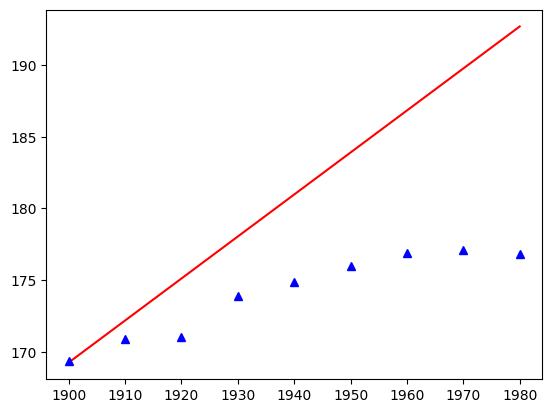

In [ ]:
heights = uk_data['Human height']
years = uk_data.index
xs = [1900, 1980]
ys = [169.25, m*1980-b]
plt.plot(xs, ys, 'r')
plt.plot(years, heights, 'b^')

4. Compute the mean square error of this model.

In [ ]:
def findErrors(m,b):
  errors= []
  for year in uk_data.index:
    height = uk_data.loc[year, "Human height"]
    prediction = m * year - b
    squared_error = (prediction - height) ** 2
    errors.append(squared_error )
  agg=np.sum(errors)
  print(errors)
  mse=(1/len(errors))*agg
  return mse
print(findErrors(m,b))
print(m)
print(b)

[np.float64(252.03150025003302), np.float64(234.376962890656), np.float64(259.4757180625338), np.float64(200.8207837656545), np.float64(198.07747600002915), np.float64(193.40117226565383), np.float64(194.3166300625294), np.float64(215.28592439065616), np.float64(252.03150025003302)]
222.20196310419766
0.09328750000000027
-7.996250000000515


5. (Optional) Modify `m` and `b` so that the MSE can be reduced.

In [ ]:

def optimizer(m,b,target):
  amountM = 5
  amountB = 5
  currentClosest=findErrors(m,b)


  if findErrors(m,b) == target:
    return findErrors(m,b)
  for i in range(20):

    if findErrors(m,b+amountB)<findErrors(m+amountM,b):
      if findErrors(m,b+amountB)<findErrors(m,b):
        currentClosest=findErrors(m,b+amountB)
        b+=amountB
        amountM-=.25


    elif findErrors(m,b+amountB)>findErrors(m+amountM,b):
      if findErrors(m+amountM,b)<findErrors(m,b):
        currentClosest=findErrors(m,b+amountB)
        m+=amountM
        amountB-=.25


  return [findErrors(m,b),m,b]
print(optimizer(m,b,0)[0])









[np.float64(252.03150025003302), np.float64(234.376962890656), np.float64(259.4757180625338), np.float64(200.8207837656545), np.float64(198.07747600002915), np.float64(193.40117226565383), np.float64(194.3166300625294), np.float64(215.28592439065616), np.float64(252.03150025003302)]
[np.float64(252.03150025003302), np.float64(234.376962890656), np.float64(259.4757180625338), np.float64(200.8207837656545), np.float64(198.07747600002915), np.float64(193.40117226565383), np.float64(194.3166300625294), np.float64(215.28592439065616), np.float64(252.03150025003302)]
[np.float64(118.27650025002262), np.float64(106.28321289064586), np.float64(123.39321806252332), np.float64(84.10953376564409), np.float64(82.3374760000188), np.float64(79.33242226564347), np.float64(79.91913006251886), np.float64(93.55967439064555), np.float64(118.27650025002262)]
[np.float64(90551886.53150028), np.float64(91495143.4394629), np.float64(92469537.87571809), np.float64(93396203.53328378), np.float64(94363233.67747

In [ ]:
heights = uk_data['Human height']
years = uk_data.index
m,b=optimizer(m,b,0)[1],optimizer(m,b,0)[2]
xs = [1900, 1980]
ys = [169.25, m*1980-b]


[np.float64(0.7665002500018206), np.float64(0.09571289062562606), np.float64(1.228218062502327), np.float64(0.6870337656232745), np.float64(0.8574759999980823), np.float64(1.1949222656227332), np.float64(1.1241300624977624), np.float64(0.10717439062430446), np.float64(0.7665002500018206)]
[np.float64(0.7665002500018206), np.float64(0.09571289062562606), np.float64(1.228218062502327), np.float64(0.6870337656232745), np.float64(0.8574759999980823), np.float64(1.1949222656227332), np.float64(1.1241300624977624), np.float64(0.10717439062430446), np.float64(0.7665002500018206)]
[np.float64(17.01150024999142), np.float64(22.00196289061551), np.float64(15.145718062491829), np.float64(33.97578376561287), np.float64(35.117475999987725), np.float64(37.12617226561237), np.float64(36.72663006248721), np.float64(28.380924390613682), np.float64(17.01150024999142)]
[np.float64(90266635.26650028), np.float64(91208409.1582129), np.float64(92181279.62821808), np.float64(93106503.39953378), np.float64(94

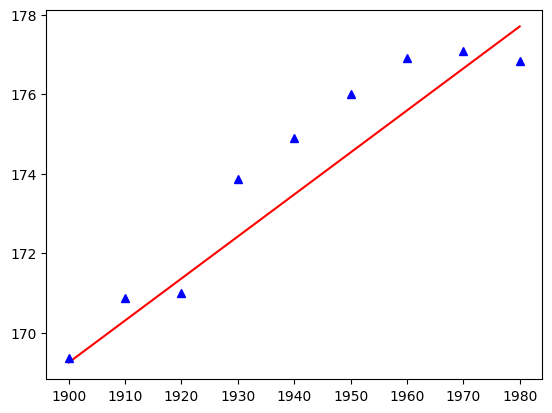

In [ ]:
plt.plot(xs, ys, 'r')
plt.plot(years, heights, 'b^')

In [ ]:
print(findErrors(m,b))
print(m)
print(b)

[np.float64(0.7665002500018206), np.float64(0.09571289062562606), np.float64(1.228218062502327), np.float64(0.6870337656232745), np.float64(0.8574759999980823), np.float64(1.1949222656227332), np.float64(1.1241300624977624), np.float64(0.10717439062430446), np.float64(0.7665002500018206)]
0.7586297708330834
0.09328750000000027
7.003749999999485
